# Modèle de régression logistique

### Objectif, regrouper des zones similaires pour faciliter l'apport de solution de lutte contre le réchauffement climatique

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import dataset
df = pd.read_csv('Dataset_LST_Final_1500plus.csv')
df.head()

,Country,Region_Type,City_Zone,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
0,France,Urban_Temperate,Paris,48.8566,2.3522,46.0,0,-0.0007,0.0932,38.28,50,200,8.92
1,France,Urban_Temperate,Paris,48.8566,2.3522,46.0,31,0.0573,0.0924,12.59,50,200,9.36
2,France,Urban_Temperate,Paris,48.8566,2.3522,46.0,59,0.0767,0.0928,45.05,50,200,17.21
3,France,Urban_Temperate,Paris,48.8566,2.3522,46.0,90,0.1781,0.2000,4.83,50,200,22.17
4,France,Urban_Temperate,Paris,48.8566,2.3522,46.0,120,0.2048,0.0700,26.29,50,200,24.77


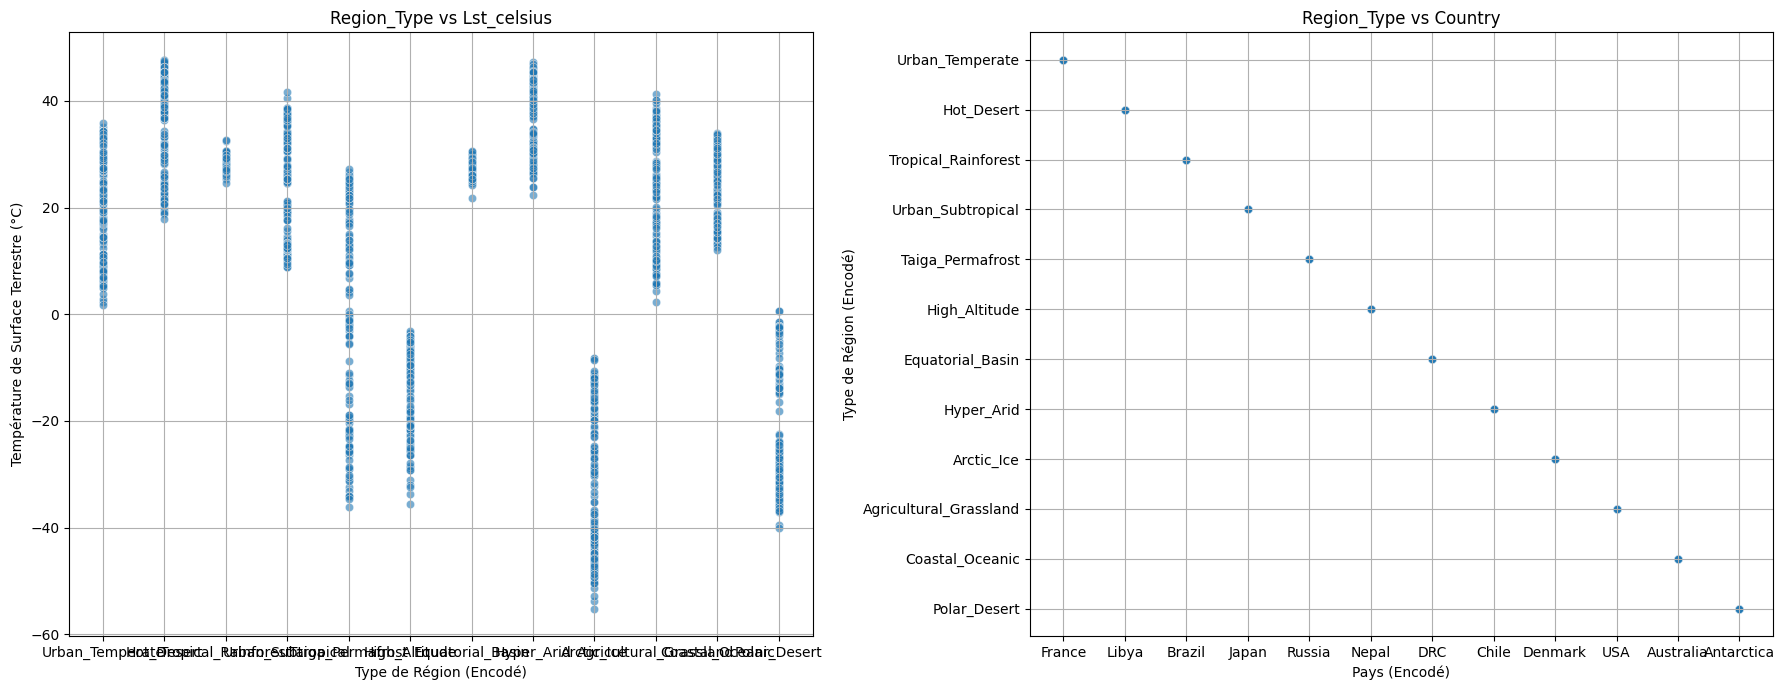

In [3]:
# Créer une figure avec deux sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Region_Type vs Lst_celsius
sns.scatterplot(x='Region_Type', y='Lst_celsius', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Region_Type vs Lst_celsius')
axes[0].set_xlabel('Type de Région (Encodé)')
axes[0].set_ylabel('Température de Surface Terrestre (°C)')
axes[0].grid(True)

# Plot 2: Region_Type vs Country
sns.scatterplot(x='Country', y='Region_Type', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('Region_Type vs Country')
axes[1].set_xlabel('Pays (Encodé)')
axes[1].set_ylabel('Type de Région (Encodé)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [4]:
# éléments vides, max, min (describe)
df.describe()

,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
count,1571.000000,1571.000000,1307.000000,1571.000000,1571.000000,1571.000000,1571.000000,1571.0,1571.0,1571.000000
mean,13.962764,34.409523,1336.244070,167.316996,0.256397,0.212651,28.770687,50.0,200.0,12.627403
std,41.591094,88.622129,2518.692982,105.065142,0.296815,0.245605,15.372749,0.0,0.0,24.946515
min,-77.846400,-98.000000,38.000000,0.000000,-0.115700,0.007500,2.100000,50.0,200.0,-55.190000
25%,-23.000000,-40.000000,52.000000,90.000000,0.000000,0.063350,15.205000,50.0,200.0,-6.660000
50%,23.000000,12.000000,306.000000,181.000000,0.138700,0.162000,29.080000,50.0,200.0,23.480000
75%,48.856600,139.691700,832.000000,273.000000,0.432450,0.263600,42.420000,50.0,200.0,29.605000
max,72.000000,166.666700,8729.000000,335.000000,0.941800,0.984700,54.950000,50.0,200.0,47.720000


In [5]:
# --- SECTION DE CONVERSION (À PLACER APRÈS LE NETTOYAGE) ---
from sklearn.preprocessing import LabelEncoder

# On crée un dictionnaire pour stocker les encodeurs de chaque colonne
le_dict = {}
object_cols = ['Country', 'Region_Type', 'City_Zone']

for col in object_cols:
    if col in df.columns:
        le = LabelEncoder()

        # On s'assure de travailler sur du texte propre
        df[col] = df[col].astype(str).str.strip()

        # On transforme et on sauvegarde l'encodeur
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

        # On affiche le dictionnaire de correspondance pour TON information
        mapping = dict(zip(le.classes_, range(len(le.classes_))))
        print(f"✅ Correspondance pour {col} : {mapping}")

le_dict['mean_altitude_m_for_imputation'] = df['Altitude_m'].mean()
print(f"✅ Moyenne d'Altitude_m pour l'imputation ajoutée à le_dict : {le_dict['mean_altitude_m_for_imputation']:.2f}")

print("\nColonnes encodées avec succès.")

print("DataFrame X after Label Encoding:")
print(df.head())
print("\nUpdated Data Types:")
print(df.dtypes)

✅ Correspondance pour Country : {'Antarctica': 0, 'Australia': 1, 'Brazil': 2, 'Chile': 3, 'DRC': 4, 'Denmark': 5, 'France': 6, 'Japan': 7, 'Libya': 8, 'Nepal': 9, 'Russia': 10, 'USA': 11}
✅ Correspondance pour Region_Type : {'Agricultural_Grassland': 0, 'Arctic_Ice': 1, 'Coastal_Oceanic': 2, 'Equatorial_Basin': 3, 'High_Altitude': 4, 'Hot_Desert': 5, 'Hyper_Arid': 6, 'Polar_Desert': 7, 'Taiga_Permafrost': 8, 'Tropical_Rainforest': 9, 'Urban_Subtropical': 10, 'Urban_Temperate': 11}
✅ Correspondance pour City_Zone : {'Amazonie': 0, 'Atacama': 1, 'Congo': 2, 'Greenland': 3, 'Himalaya': 4, 'Kansas_Plains': 5, 'McMurdo': 6, 'Paris': 7, 'Sahara': 8, 'Siberie': 9, 'Sydney': 10, 'Tokyo': 11}
✅ Moyenne d'Altitude_m pour l'imputation ajoutée à le_dict : 1336.24

Colonnes encodées avec succès.
DataFrame X after Label Encoding:
   Country  Region_Type  City_Zone  Latitude  Longitude  Altitude_m  \
0        6           11          7   48.8566     2.3522        46.0   
1        6           11      

In [6]:
def impute_altitude_with_mean(df_to_impute):
    # Calculate the mean of 'Altitude_m' from the dataframe
    mean_altitude = df_to_impute['Altitude_m'].mean()

    # Fill NaN values in 'Altitude_m' with the calculated mean
    df_to_impute['Altitude_m'] = df_to_impute['Altitude_m'].fillna(mean_altitude)
    return df_to_impute

# Apply the imputation function to the 'df' DataFrame
df = impute_altitude_with_mean(df)

print("NaN values in 'Altitude_m' column after imputation (df):")
print(df['Altitude_m'].isna().sum())

NaN values in 'Altitude_m' column after imputation (df):
0


In [7]:
# Split x et y
X = df.drop(['Region_Type'],axis=1)
y = df['Region_Type']
print(X.head())
print(y.head())

   Country  City_Zone  Latitude  Longitude  Altitude_m  Day_of_year    Ndvi  \
0        6          7   48.8566     2.3522        46.0            0 -0.0007   
1        6          7   48.8566     2.3522        46.0           31  0.0573   
2        6          7   48.8566     2.3522        46.0           59  0.0767   
3        6          7   48.8566     2.3522        46.0           90  0.1781   
4        6          7   48.8566     2.3522        46.0          120  0.2048   

   Albedo  Cloud_cover_pct  Humidity_pct  Insolation_wm2  Lst_celsius  
0  0.0932            38.28            50             200         8.92  
1  0.0924            12.59            50             200         9.36  
2  0.0928            45.05            50             200        17.21  
3  0.2000             4.83            50             200        22.17  
4  0.0700            26.29            50             200        24.77  
0    11
1    11
2    11
3    11
4    11
Name: Region_Type, dtype: int32


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=24)

# Colonnes numériques à mettre à l'échelle, y compris les catégorielles encodées qui ne sont pas constantes
numerical_cols_to_scale = ['Country', 'City_Zone', 'Latitude', 'Longitude', 'Altitude_m', 'Day_of_year', 'Ndvi', 'Albedo', 'Cloud_cover_pct', 'Lst_celsius']

scaler = StandardScaler()

# Créer des copies des ensembles d'entraînement et de test pour y appliquer la mise à l'échelle
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

# Appliquer le StandardScaler sur les colonnes numériques identifiées
# Fit le scaler sur l'ensemble d'entraînement et le transforme
x_train_scaled[numerical_cols_to_scale] = scaler.fit_transform(x_train[numerical_cols_to_scale])
# Transformer l'ensemble de test avec le scaler déjà entraîné
x_test_scaled[numerical_cols_to_scale] = scaler.transform(x_test[numerical_cols_to_scale])

In [9]:
x_train_scaled.head()

,Country,City_Zone,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
1065,-0.159630,-0.738915,1.406165,-0.832404,-0.005260,1.319382,-0.861667,-0.044230,0.383749,50,200,-2.378500
161,0.710829,0.719409,0.209950,-0.242227,-0.223046,-0.121786,-0.539254,0.234491,-1.604770,50,200,1.254990
559,1.291135,1.011074,1.113215,0.756534,-0.450229,-1.269031,-0.479737,0.220845,0.740813,50,200,-1.318749
689,1.000982,-0.447250,0.331722,0.608139,3.187713,-1.269031,-1.071848,-0.044230,-0.235594,50,200,-1.350936
531,1.291135,1.011074,1.113215,0.756534,-0.450229,1.025460,0.840863,-0.587199,1.652299,50,200,-0.607822


In [10]:
# Entraînement du modèle de régression logistique
logistic_model = LogisticRegression(solver='liblinear', random_state=24, max_iter=1000)
logistic_model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=24, solver='liblinear')

In [11]:
# Evaluation du modele
y_pred = logistic_model.predict(x_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        23
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        26
           7       1.00      1.00      1.00        35
           8       1.00      1.00      1.00        28
           9       1.00      1.00      1.00        31
          10       1.00      1.00      1.00        32
          11       1.00      1.00      1.00        26

    accuracy                           1.00       315
   macro avg       1.00      1.00      1.00       315
weighted avg       1.00      1.00      1.00       315



<Axes: >

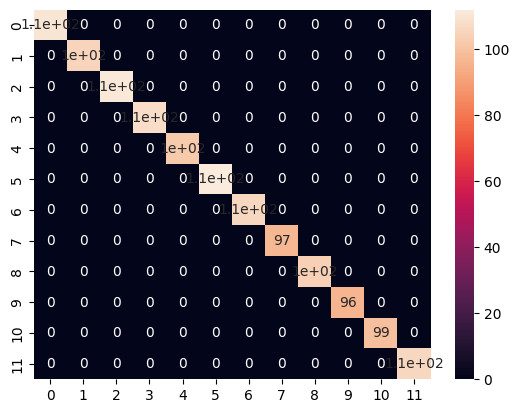

In [12]:
# Evaluationm du modele
y_predict_train = logistic_model.predict(x_train_scaled)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train,y_predict_train)
sns.heatmap(cm,annot=True)

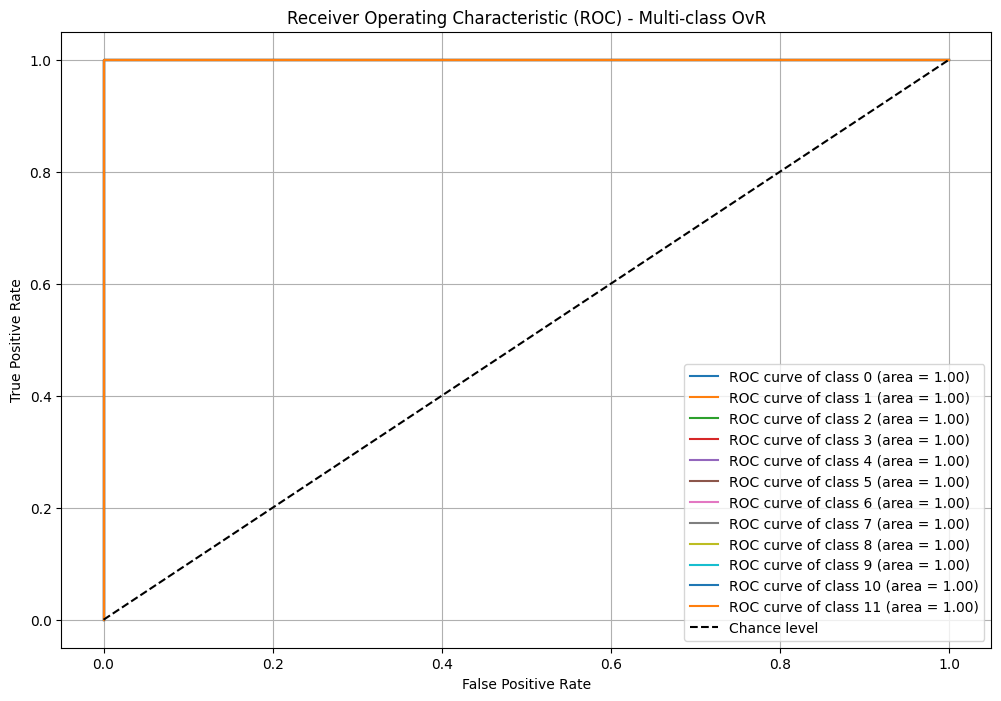

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Obtenir les probabilités de prédiction pour chaque classe
y_score = logistic_model.predict_proba(x_test_scaled)

# Binariser les vraies étiquettes pour chaque classe (One-Hot Encoding)
y_test_binarized = label_binarize(y_test, classes=logistic_model.classes_)

# Initialiser un dictionnaire pour stocker les FPR, TPR et AUC pour chaque classe
roc_data = {}

plt.figure(figsize=(12, 8))

# Pour chaque classe, calculer et tracer la courbe ROC
for i in range(len(logistic_model.classes_)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    roc_data[i] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
    plt.plot(fpr, tpr, label=f'ROC curve of class {i} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class OvR')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [14]:
import random

# Définir les plages ou valeurs pour la génération de données aléatoires
# Basé sur df.describe() et les colonnes encodées
feature_ranges = {
    'Country': (0, 11),  # LabelEncoded de 0 à 11
    'City_Zone': (0, 11), # LabelEncoded de 0 à 11
    'Latitude': (-77.8464, 72.0000), # min/max observés
    'Longitude': (-98.0000, 166.6667), # min/max observés
    'Altitude_m': (38.0, 8729.0), # min/max observés
    'Day_of_year': (0, 335), # min/max observés
    'Ndvi': (-0.1157, 0.9418), # min/max observés
    'Albedo': (0.0075, 0.9847), # min/max observés
    'Cloud_cover_pct': (2.10, 54.95), # min/max observés
    'Humidity_pct': 50, # Valeur constante
    'Insolation_wm2': 200, # Valeur constante
    'Lst_celsius': (-55.19, 47.72) # min/max observés
}

# Nombre de points de données aléatoires à générer
num_random_samples = 5

random_data_unscaled = pd.DataFrame(columns=X.columns)

for i in range(num_random_samples):
    sample = {}
    for col in X.columns:
        if col == 'Humidity_pct' or col == 'Insolation_wm2':
            sample[col] = feature_ranges[col]
        elif col in ['Country', 'City_Zone']:
            sample[col] = random.randint(feature_ranges[col][0], feature_ranges[col][1])
        else:
            sample[col] = random.uniform(feature_ranges[col][0], feature_ranges[col][1])
    random_data_unscaled = pd.concat([random_data_unscaled, pd.DataFrame([sample])], ignore_index=True)

print("Données aléatoires non mises à l'échelle (5 échantillons) :")
display(random_data_unscaled)

# Assurez-vous que les types de données sont corrects pour la mise à l'échelle
# Les colonnes categoricales encodées doivent être des entiers
for col in ['Country', 'City_Zone']:
    random_data_unscaled[col] = random_data_unscaled[col].astype(int)

# Mise à l'échelle des données aléatoires en utilisant le scaler entraîné sur x_train
random_data_scaled = random_data_unscaled.copy()
# Appliquer le scaler uniquement aux colonnes qui ont été scaled lors de l'entraînement
random_data_scaled[numerical_cols_to_scale] = scaler.transform(random_data_unscaled[numerical_cols_to_scale])

print("\nDonnées aléatoires mises à l'échelle :")
display(random_data_scaled)

# Faire des prédictions
random_predictions = logistic_model.predict(random_data_scaled)

print("\nPrédictions du modèle pour les données aléatoires :")
# On peut utiliser le le_dict['Region_Type'] pour décoder si on l'avait gardé
# Comme Region_Type est la cible, nous n'avons pas d'encodeur pour elle dans le_dict
# Nous allons donc afficher les labels numériques prédits.
# Si vous voulez les noms de régions réels, vous devrez reconstruire le mapping inverse.
print(random_predictions)

Données aléatoires non mises à l'échelle (5 échantillons) :


C:\Users\jotat\AppData\Local\Temp\ipykernel_9836\2318597418.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  random_data_unscaled = pd.concat([random_data_unscaled, pd.DataFrame([sample])], ignore_index=True)


,Country,City_Zone,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
0,8,6,-51.652128,-77.328489,6390.452030,59.415419,0.774930,0.809959,32.532667,50,200,11.156918
1,9,10,30.367240,-97.982046,2628.809393,150.255431,0.160689,0.504537,15.888431,50,200,32.529027
2,1,9,40.498859,74.714265,7451.707256,48.849081,0.034249,0.683575,32.846926,50,200,-36.634944
3,3,4,69.470100,-97.706142,3543.711144,36.834660,0.755967,0.662037,32.333969,50,200,41.057488
4,1,8,-32.704041,-67.978908,3000.454455,220.310635,0.372373,0.056692,23.263480,50,200,11.338598



Données aléatoires mises à l'échelle :


,Country,City_Zone,Latitude,Longitude,Altitude_m,Day_of_year,Ndvi,Albedo,Cloud_cover_pct,Humidity_pct,Insolation_wm2,Lst_celsius
0,0.710829,0.136079,-1.612500,-1.256066,2.177681,-0.999614,1.773855,2.478151,0.242395,50,200,-0.070829
1,1.000982,1.302739,0.389803,-1.490474,0.553006,-0.138327,-0.315167,1.215132,-0.838159,50,200,0.789047
2,-1.320243,1.011074,0.637142,0.469552,2.636043,-1.099797,-0.745186,1.955513,0.262797,50,200,-1.993664
3,-0.739937,-0.447250,1.344404,-1.487343,0.948157,-1.213710,1.709361,1.866446,0.229496,50,200,1.132177
4,-1.320243,0.719409,-1.149929,-1.149952,0.713521,0.525892,0.404764,-0.636855,-0.359366,50,200,-0.063519



Prédictions du modèle pour les données aléatoires :
[5 5 4 9 2]


In [15]:
import pickle

# Enregistrer le modèle de régression logistique
with open('logistic_model.pkl', 'wb') as file:
    pickle.dump(logistic_model, file)
print("Modèle 'logistic_model.pkl' enregistré avec succès.")

# Enregistrer le scaler
with open('scaler_log.pkl', 'wb') as file:
    pickle.dump(scaler, file)
print("Scaler 'scaler.pkl' enregistré avec succès.")

# Enregistrer le dictionnaire des LabelEncoders (très important pour les catégories)
with open('le_dict_log.pkl', 'wb') as file:
    pickle.dump(le_dict, file)
print("Dictionnaire d'encodeurs 'le_dict.pkl' enregistré avec succès.")

Modèle 'logistic_model.pkl' enregistré avec succès.
Scaler 'scaler.pkl' enregistré avec succès.
Dictionnaire d'encodeurs 'le_dict.pkl' enregistré avec succès.
